# Preprocessing Analysis - Code Filtering Results

This notebook analyzes the preprocessed WildChat dataset after applying code filtering.

**Dataset:** `wildchat_full_preprocessed.csv`  
**Original:** ~1M conversations  
**After Preprocessing:** ~144k turn pairs

## Preprocessing Steps Applied:

1. **Turn Pair Extraction** - Extract (user prompt → LLM response → user reply) triplets
2. **Language Filtering** - Keep only English conversations
3. **Code Filtering** - Remove conversations with code blocks
4. **Quality Filtering** - Remove toxic/inappropriate content
5. **Length Filtering** - Ensure meaningful conversation length

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## Load Preprocessed Dataset

In [2]:
# Load the preprocessed dataset
data_path = '../data/filtered/wildchat_full_preprocessed.csv'

print(f"Loading dataset from: {data_path}")
df = pd.read_csv(data_path)

print(f"\nDataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"Total turn pairs: {len(df):,}")

Loading dataset from: ../data/filtered/wildchat_full_preprocessed.csv

Dataset loaded successfully!
Shape: (144439, 14)
Total turn pairs: 144,439

Dataset loaded successfully!
Shape: (144439, 14)
Total turn pairs: 144,439


## Dataset Overview

In [3]:
print("="*70)
print("DATASET STRUCTURE")
print("="*70)

print(f"\nColumns: {list(df.columns)}")
print(f"\nData types:")
print(df.dtypes)
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

DATASET STRUCTURE

Columns: ['conversation_hash', 'turn_pair_id', 'model', 'user_id', 'turn_number', 'total_turns', 'timestamp', 'hour_of_day', 'user_prompt', 'llm_response', 'user_reply', 'turn_identifier', 'hashed_ip', 'country']

Data types:
conversation_hash    object
turn_pair_id         object
model                object
user_id              object
turn_number           int64
total_turns           int64
timestamp            object
hour_of_day           int64
user_prompt          object
llm_response         object
user_reply           object
turn_identifier       int64
hashed_ip            object
country              object
dtype: object

Memory usage: 321.4 MB


In [4]:
# First few rows
print("First 5 turn pairs:")
df.head()

First 5 turn pairs:


,conversation_hash,turn_pair_id,model,user_id,turn_number,total_turns,timestamp,hour_of_day,user_prompt,llm_response,user_reply,turn_identifier,hashed_ip,country
0,aa7c3f49343e097be66442288abd1dac,aa7c3f49343e097be66442288abd1dac_101047,gpt-4-0314,1ed6e074d3f80ccbb81e5541523236b2,11,14,2023-04-09 00:20:40,0,"calculate the payment, interest,etc for a mortgage that is 500000 at 5 percent interest, 300 mon...","To calculate the monthly mortgage payment, we can use the following formula:\n\nM = P * (r * (1+...","calculate the payment, interest,etc for a mortgage that is 500000 at 5 percent interest, 300 mon...",101047,e49e258fbabeb7e0916d44b43e30ad77e61026bd8cb07cc4086fde524b2b0b07,Canada
1,576e59afd66835b3797517cd1cd8a08b,576e59afd66835b3797517cd1cd8a08b_101085,gpt-4-0314,c33b89db9001764270c83505d2992d0c,3,6,2023-04-09 00:29:51,0,how long does it take to run in a circle,"The time it takes to run in a circle depends on several factors, including the size of the circl...",hello how are you,101085,09e0bc9c473bbbcb360a8ac668b2c90c8ee8b3fc34b6a3bbc54946db3dafdb0b,United States
2,94e4291a6e14137c52e57fb86548e91f,94e4291a6e14137c52e57fb86548e91f_101087,gpt-4-0314,740f8e00b25c0d737084507b9c9b066c,1,6,2023-04-09 00:30:10,0,Hi there,"Hello! How can I help you today? If you have any questions or need assistance, feel free to ask.",Maybe i need a little help,101087,9cb2a823d664474697912beebad22f0d4ea8c8220deeeed82dc71a2db7586e91,Cuba
3,94e4291a6e14137c52e57fb86548e91f,94e4291a6e14137c52e57fb86548e91f_101092,gpt-4-0314,740f8e00b25c0d737084507b9c9b066c,3,6,2023-04-09 00:30:49,0,Maybe i need a little help,"Of course, I'm here to help! Please tell me what you need assistance with, and I'll do my best t...",I was wondering if you have some advices for me,101092,9cb2a823d664474697912beebad22f0d4ea8c8220deeeed82dc71a2db7586e91,Cuba
4,3ae27f2a38590dcb18027cf906e680c9,3ae27f2a38590dcb18027cf906e680c9_101119,gpt-4-0314,b74a22c6892b786ff3c5c9ce4402d9af,3,6,2023-04-09 00:36:57,0,"So, in terms of durability and resilience, it's far more important to have backups, and therefor...","Yes, in terms of durability and resilience, having multiple backups is far more important than s...",You are a champion and a scholar.,101119,a8ee39056ccfb355c8cc177355aad239ec6ba7035a85a3dff579ca8a24672260,United States


## Basic Statistics

In [6]:
print("="*70)
print("BASIC STATISTICS")
print("="*70)

print(f"\nTotal turn pairs: {len(df):,}")
print(f"Unique conversations: {df['conversation_hash'].nunique():,}")
print(f"Unique models: {df['model'].nunique()}")

print(f"\nMissing values:")
print(df.isnull().sum())

print(f"\nDuplicate rows: {df.duplicated().sum():,}")

BASIC STATISTICS

Total turn pairs: 144,439
Unique conversations: 66,111
Unique models: 6

Missing values:
conversation_hash       0
turn_pair_id            0
model                   0
user_id                 0
turn_number             0
total_turns             0
timestamp               0
hour_of_day             0
user_prompt          1962
llm_response            1
user_reply           1938
turn_identifier         0
hashed_ip               0
country               168
dtype: int64

Duplicate rows: 0

Duplicate rows: 0


## Model Distribution

In [7]:
print("="*70)
print("MODEL DISTRIBUTION")
print("="*70)

model_counts = df['model'].value_counts()
model_pct = (model_counts / len(df) * 100).round(2)

print(f"\n{'Model':<40} {'Count':>12} {'Percentage':>12}")
print("-"*66)
for model, count in model_counts.items():
    pct = model_pct[model]
    bar = '█' * int(pct / 2)
    print(f"{model:<40} {count:>12,} {pct:>11.2f}% {bar}")
print("-"*66)
print(f"{'Total':<40} {len(df):>12,} {'100.00%':>12}")

MODEL DISTRIBUTION

Model                                           Count   Percentage
------------------------------------------------------------------
gpt-3.5-turbo-0613                             63,106       43.69% █████████████████████
gpt-3.5-turbo-0301                             42,165       29.19% ██████████████
gpt-4-1106-preview                             16,631       11.51% █████
gpt-4-0125-preview                             11,266        7.80% ███
gpt-3.5-turbo-0125                              6,336        4.39% ██
gpt-4-0314                                      4,935        3.42% █
------------------------------------------------------------------
Total                                         144,439      100.00%


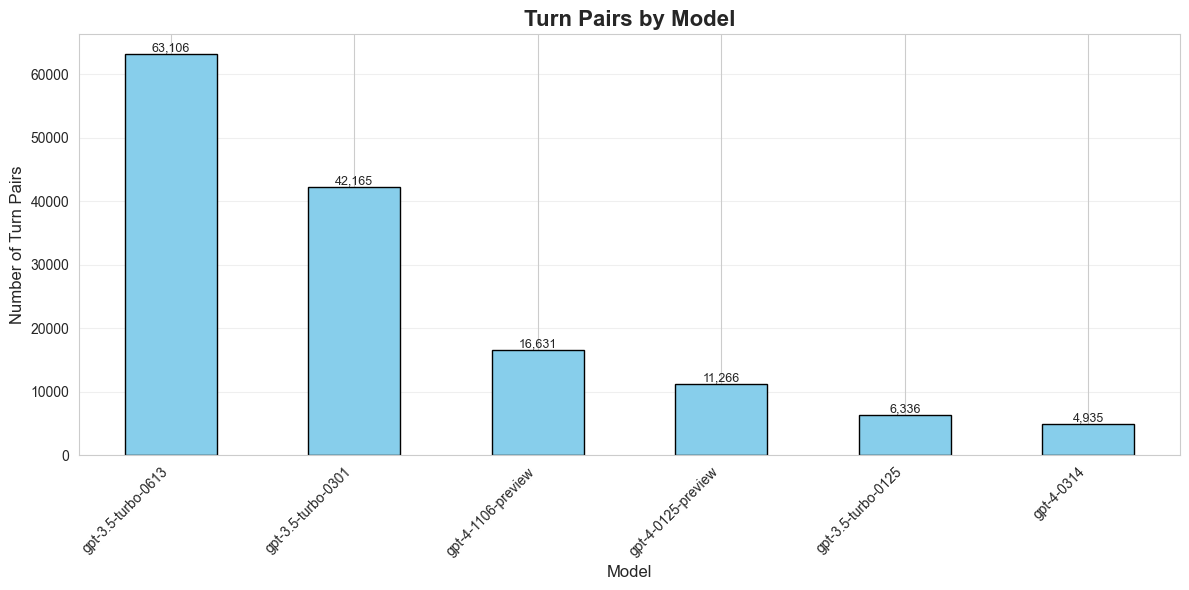

✓ Saved plot: outputs/preprocessing_model_distribution.png


In [8]:
# Visualize model distribution
fig, ax = plt.subplots(figsize=(12, 6))

model_counts.plot(kind='bar', ax=ax, color='skyblue', edgecolor='black')
ax.set_title('Turn Pairs by Model', fontsize=16, fontweight='bold')
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Number of Turn Pairs', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (model, count) in enumerate(model_counts.items()):
    ax.text(i, count, f'{count:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/preprocessing_model_distribution.png', dpi=200, bbox_inches='tight')
plt.show()

print("✓ Saved plot: outputs/preprocessing_model_distribution.png")

## Text Length Analysis

In [9]:
# Calculate text lengths
df['user_prompt_len'] = df['user_prompt'].str.len()
df['llm_response_len'] = df['llm_response'].str.len()
df['user_reply_len'] = df['user_reply'].str.len()

print("="*70)
print("TEXT LENGTH STATISTICS (characters)")
print("="*70)

print(f"\nUser Prompt:")
print(df['user_prompt_len'].describe())

print(f"\nLLM Response:")
print(df['llm_response_len'].describe())

print(f"\nUser Reply:")
print(df['user_reply_len'].describe())

TEXT LENGTH STATISTICS (characters)

User Prompt:
count    142477.000000
mean        158.523011
std         413.213691
min           1.000000
25%          31.000000
50%          63.000000
75%         142.000000
max       57284.000000
Name: user_prompt_len, dtype: float64

LLM Response:
count    144438.000000
mean        899.666217
std         932.900127
min           2.000000
25%         171.000000
50%         572.000000
75%        1358.000000
max       20339.000000
Name: llm_response_len, dtype: float64

User Reply:
count    142501.000000
mean        146.235956
std         476.952635
min           1.000000
25%          32.000000
50%          62.000000
75%         133.000000
max      100596.000000
Name: user_reply_len, dtype: float64


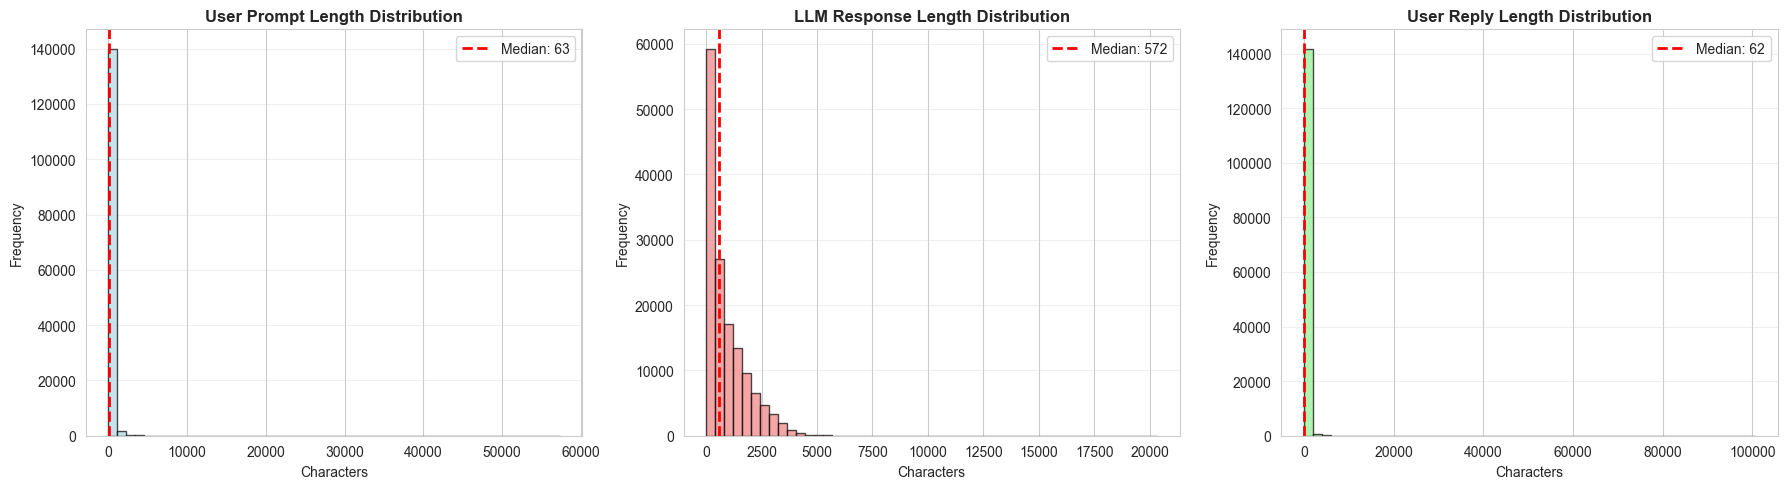

✓ Saved plot: outputs/preprocessing_length_distributions.png


In [10]:
# Visualize length distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# User Prompt
axes[0].hist(df['user_prompt_len'], bins=50, color='lightblue', edgecolor='black', alpha=0.7)
axes[0].set_title('User Prompt Length Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Characters', fontsize=10)
axes[0].set_ylabel('Frequency', fontsize=10)
axes[0].axvline(df['user_prompt_len'].median(), color='red', linestyle='--', 
                linewidth=2, label=f'Median: {df["user_prompt_len"].median():.0f}')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# LLM Response
axes[1].hist(df['llm_response_len'], bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
axes[1].set_title('LLM Response Length Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Characters', fontsize=10)
axes[1].set_ylabel('Frequency', fontsize=10)
axes[1].axvline(df['llm_response_len'].median(), color='red', linestyle='--', 
                linewidth=2, label=f'Median: {df["llm_response_len"].median():.0f}')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# User Reply
axes[2].hist(df['user_reply_len'], bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
axes[2].set_title('User Reply Length Distribution', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Characters', fontsize=10)
axes[2].set_ylabel('Frequency', fontsize=10)
axes[2].axvline(df['user_reply_len'].median(), color='red', linestyle='--', 
                linewidth=2, label=f'Median: {df["user_reply_len"].median():.0f}')
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/preprocessing_length_distributions.png', dpi=200, bbox_inches='tight')
plt.show()

print("✓ Saved plot: outputs/preprocessing_length_distributions.png")

## Language Distribution

In [11]:
if 'language' in df.columns:
    print("="*70)
    print("LANGUAGE DISTRIBUTION")
    print("="*70)
    
    lang_counts = df['language'].value_counts()
    lang_pct = (lang_counts / len(df) * 100).round(2)
    
    print(f"\n{'Language':<20} {'Count':>12} {'Percentage':>12}")
    print("-"*46)
    for lang, count in lang_counts.head(10).items():
        pct = lang_pct[lang]
        bar = '█' * int(pct / 2)
        print(f"{lang:<20} {count:>12,} {pct:>11.2f}% {bar}")
    print("-"*46)
    print(f"{'Total':<20} {len(df):>12,} {'100.00%':>12}")
else:
    print("ℹ️  'language' column not found in dataset")

ℹ️  'language' column not found in dataset


## Sample Conversations

In [12]:
print("="*70)
print("SAMPLE CONVERSATIONS")
print("="*70)

# Show 3 random examples
samples = df.sample(n=3, random_state=42)

for idx, (i, row) in enumerate(samples.iterrows(), 1):
    print(f"\n{'='*70}")
    print(f"EXAMPLE {idx}")
    print(f"{'='*70}")
    print(f"Model: {row['model']}")
    print(f"Conversation Hash: {row['conversation_hash']}")
    print(f"\n[USER PROMPT]")
    print(row['user_prompt'][:300] + ("..." if len(row['user_prompt']) > 300 else ""))
    print(f"\n[LLM RESPONSE]")
    print(row['llm_response'][:300] + ("..." if len(row['llm_response']) > 300 else ""))
    print(f"\n[USER REPLY]")
    print(row['user_reply'][:300] + ("..." if len(row['user_reply']) > 300 else ""))

SAMPLE CONVERSATIONS

EXAMPLE 1
Model: gpt-3.5-turbo-0613
Conversation Hash: aad359b56adeb708729e4849715327b8

[USER PROMPT]
Cross-site scripting (DOM-based)

[LLM RESPONSE]
Cross-Site Scripting (XSS) is a type of security vulnerability that allows attackers to inject malicious scripts into trusted websites or web applications. DOM-based XSS, also known as client-side XSS, is a specific form of XSS that occurs when the vulnerability is present in the client-side JavaScr...

[USER REPLY]
Cross-site scripting (DOM-based)

EXAMPLE 2
Model: gpt-4-0314
Conversation Hash: d77d9344c60f4fbd02accaa4f17c2c30

[USER PROMPT]
condense but keep the necessary details and complexity of the following resume entry: Organized a disaster preparedness fair, attracting over a hundred students and community members, emphasizing earthquake and fire safety awareness, distributing materials to equip individuals with the necessary kno...

[LLM RESPONSE]
Organized a disaster preparedness fair, engaging 100+ stude

## Code Filtering Verification

In [13]:
print("="*70)
print("CODE FILTERING VERIFICATION")
print("="*70)

# Check for code indicators
code_indicators = ['```', '`', 'def ', 'import ', 'function ', 'class ', '#!/']

for indicator in code_indicators:
    count_prompt = df['user_prompt'].str.contains(indicator, case=False, na=False).sum()
    count_response = df['llm_response'].str.contains(indicator, case=False, na=False).sum()
    count_reply = df['user_reply'].str.contains(indicator, case=False, na=False).sum()
    
    total = count_prompt + count_response + count_reply
    pct = (total / (len(df) * 3)) * 100
    
    print(f"\n'{indicator}':")
    print(f"  User Prompts:  {count_prompt:>6,} ({count_prompt/len(df)*100:>5.2f}%)")
    print(f"  LLM Responses: {count_response:>6,} ({count_response/len(df)*100:>5.2f}%)")
    print(f"  User Replies:  {count_reply:>6,} ({count_reply/len(df)*100:>5.2f}%)")
    print(f"  Total:         {total:>6,} ({pct:>5.2f}% of all texts)")

print(f"\n{'='*70}")
print("Note: Some code indicators may remain in natural language contexts")
print("(e.g., 'import' in 'import/export', 'class' in 'class of students')")

CODE FILTERING VERIFICATION

'```':
  User Prompts:       0 ( 0.00%)
  LLM Responses:      0 ( 0.00%)
  User Replies:       0 ( 0.00%)
  Total:              0 ( 0.00% of all texts)

'`':
  User Prompts:      98 ( 0.07%)
  LLM Responses:  1,744 ( 1.21%)
  User Replies:      88 ( 0.06%)
  Total:          1,930 ( 0.45% of all texts)

'```':
  User Prompts:       0 ( 0.00%)
  LLM Responses:      0 ( 0.00%)
  User Replies:       0 ( 0.00%)
  Total:              0 ( 0.00% of all texts)

'`':
  User Prompts:      98 ( 0.07%)
  LLM Responses:  1,744 ( 1.21%)
  User Replies:      88 ( 0.06%)
  Total:          1,930 ( 0.45% of all texts)

'def ':
  User Prompts:       0 ( 0.00%)
  LLM Responses:      0 ( 0.00%)
  User Replies:       0 ( 0.00%)
  Total:              0 ( 0.00% of all texts)

'def ':
  User Prompts:       0 ( 0.00%)
  LLM Responses:      0 ( 0.00%)
  User Replies:       0 ( 0.00%)
  Total:              0 ( 0.00% of all texts)

'import ':
  User Prompts:       0 ( 0.00%)
  LLM Respo

## Summary Statistics by Model

In [14]:
print("="*70)
print("SUMMARY STATISTICS BY MODEL")
print("="*70)

model_stats = df.groupby('model').agg({
    'turn_pair_id': 'count',
    'user_prompt_len': ['mean', 'median'],
    'llm_response_len': ['mean', 'median'],
    'user_reply_len': ['mean', 'median']
}).round(0)

model_stats.columns = ['Count', 'Prompt_Mean', 'Prompt_Median', 
                        'Response_Mean', 'Response_Median',
                        'Reply_Mean', 'Reply_Median']

print("\n", model_stats.to_string())

SUMMARY STATISTICS BY MODEL

                     Count  Prompt_Mean  Prompt_Median  Response_Mean  Response_Median  Reply_Mean  Reply_Median
model                                                                                                          
gpt-3.5-turbo-0125   6336        150.0           62.0          678.0            434.0       141.0          60.0
gpt-3.5-turbo-0301  42165        137.0           57.0          750.0            574.0       123.0          56.0
gpt-3.5-turbo-0613  63106        164.0           69.0          908.0            547.0       152.0          67.0
gpt-4-0125-preview  11266        179.0           62.0         1122.0            544.0       170.0          60.0
gpt-4-0314           4935        223.0           77.0         1177.0            882.0       192.0          72.0
gpt-4-1106-preview  16631        162.0           61.0         1098.0            699.0       158.0          60.0


## Export Summary Report

In [15]:
# Create summary report
summary = {
    'Total Turn Pairs': len(df),
    'Unique Conversations': df['conversation_hash'].nunique(),
    'Unique Models': df['model'].nunique(),
    'Avg User Prompt Length': df['user_prompt_len'].mean(),
    'Avg LLM Response Length': df['llm_response_len'].mean(),
    'Avg User Reply Length': df['user_reply_len'].mean(),
    'Missing Values': df.isnull().sum().sum(),
    'Duplicate Rows': df.duplicated().sum()
}

summary_df = pd.DataFrame(list(summary.items()), columns=['Metric', 'Value'])

# Save to CSV
summary_df.to_csv('../outputs/preprocessing_summary.csv', index=False)
print("✓ Saved summary: outputs/preprocessing_summary.csv")

# Save model distribution
model_dist = pd.DataFrame({
    'Model': model_counts.index,
    'Count': model_counts.values,
    'Percentage': model_pct.values
})
model_dist.to_csv('../outputs/preprocessing_model_distribution.csv', index=False)
print("✓ Saved model distribution: outputs/preprocessing_model_distribution.csv")

print("\n" + "="*70)
print("ANALYSIS COMPLETE!")
print("="*70)
print(f"\nDataset: {len(df):,} turn pairs ready for scoring")
print(f"Next step: Score conversations with empathy and attachment ratings")

✓ Saved summary: outputs/preprocessing_summary.csv
✓ Saved model distribution: outputs/preprocessing_model_distribution.csv

ANALYSIS COMPLETE!

Dataset: 144,439 turn pairs ready for scoring
Next step: Score conversations with empathy and attachment ratings
